# 📱 Global Mobile Reviews — Sentiment, Segmentation & Recommendations

**Project pipeline:**
1. Load & inspect raw data
2. Clean data (missing values, duplicates, date formats)
3. Exploratory Data Analysis (EDA)
4. Build a product-level summary table
5. Segment phones by price using K-Means clustering
6. Build a content-based phone recommendation system

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
print("✔ Libraries loaded!")

✔ Libraries loaded!


In [2]:
# Path to the raw dataset — update this if the file moves
BASE_PATH = r"C:\Users\Shyam\Documents\Python\VS code and SQL\Global Mobile Reviews"
RAW_FILE = BASE_PATH + r"\Mobile Reviews Sentiment null.csv"

df = pd.read_csv(RAW_FILE, encoding="latin-1")
print("✔ File loaded!")

✔ File loaded!


## 2. Initial Data Inspection

In [3]:
df.shape

(50000, 22)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  str    
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  str    
 4   model                 50000 non-null  str    
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  str    
 7   currency              50000 non-null  str    
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  str    
 11  country               50000 non-null  str    
 12  language              50000 non-null  str    
 13  review_date           50000 non-null  str    
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating   50000 no

In [5]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [6]:
# Check which other columns are also missing on rows where "rating" is missing
missing_rating = df[df["rating"].isnull()]
print(missing_rating[["price_usd", "sentiment", "source"]].isnull().sum())

price_usd    143
sentiment    127
source       123
dtype: int64


## 3. Data Cleaning

### 3.1 Drop redundant columns

In [7]:
# "price_local" is redundant once we have price_usd
df = df.drop(columns=["price_local"])

### 3.2 Fill missing `price_usd`
Use the median price for the same brand + model, falling back to the overall median if that group has no data either.

In [8]:
df["price_usd"] = df["price_usd"].fillna(
    df.groupby(["brand", "model"])["price_usd"].transform("median")
)

overall_price_median = df["price_usd"].median()
df["price_usd"] = df["price_usd"].fillna(overall_price_median)

print("Remaining missing price_usd:", df["price_usd"].isnull().sum())

Remaining missing price_usd: 0


### 3.3 Fill missing `rating`
Same strategy: median by brand + model, then overall median.

In [9]:
df["rating"] = df["rating"].fillna(
    df.groupby(["brand", "model"])["rating"].transform("median")
)

overall_rating_median = df["rating"].median()
df["rating"] = df["rating"].fillna(overall_rating_median)

print("Remaining missing rating:", df["rating"].isnull().sum())

Remaining missing rating: 0


### 3.4 Fill missing `sentiment` based on `rating`
Rating ≥ 4 → Positive, Rating == 3 → Neutral, Rating < 3 → Negative.

In [10]:
def infer_sentiment(rating):
    """Map a numeric rating to a sentiment label."""
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"


mask = df["sentiment"].isnull()
df.loc[mask, "sentiment"] = df.loc[mask, "rating"].apply(infer_sentiment)

print("Remaining missing sentiment:", df["sentiment"].isnull().sum())

Remaining missing sentiment: 0


### 3.5 Fill missing `source`
Use the most common (mode) source.

In [11]:
most_common_source = df["source"].mode()[0]
df["source"] = df["source"].fillna(most_common_source)

print("Remaining missing source:", df["source"].isnull().sum())

Remaining missing source: 0


### 3.6 Remove duplicate rows

In [12]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


### 3.7 Fix mixed date formats in `review_date`
The raw column mixes two formats: `DD-MM-YYYY` and `M/D/YYYY`. We reload the raw strings and parse each format separately, then merge the results back into a single datetime column.

In [13]:
# Reload the raw column fresh (in case it was corrupted by an earlier parse attempt)
raw_dates = pd.read_csv(RAW_FILE, encoding="latin-1")["review_date"]
df["review_date"] = raw_dates

# Split rows by which date format they use
has_dash = df["review_date"].str.contains("-")
has_slash = df["review_date"].str.contains("/")

# Parse each format separately
dash_parsed = pd.to_datetime(df.loc[has_dash, "review_date"], format="%d-%m-%Y", errors="coerce")
slash_parsed = pd.to_datetime(df.loc[has_slash, "review_date"], format="%m/%d/%Y", errors="coerce")

# Merge both parsed groups back into one column
df["review_date"] = pd.NaT
df.loc[has_dash, "review_date"] = dash_parsed
df.loc[has_slash, "review_date"] = slash_parsed

print("Unparsed dates after fix:", df["review_date"].isnull().sum())
df["review_date"].head(10)

Unparsed dates after fix: 0


0   2023-06-11
1   2023-03-30
2   2022-07-12
3   2025-11-03
4   2023-09-29
5   2023-06-27
6   2024-03-27
7   2024-08-04
8   2024-04-10
9   2025-02-25
Name: review_date, dtype: datetime64[ns]

### 3.8 Final check & save cleaned data

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   review_id             50000 non-null  int64         
 1   customer_name         50000 non-null  str           
 2   age                   50000 non-null  int64         
 3   brand                 50000 non-null  str           
 4   model                 50000 non-null  str           
 5   price_usd             50000 non-null  float64       
 6   currency              50000 non-null  str           
 7   exchange_rate_to_usd  50000 non-null  float64       
 8   rating                50000 non-null  float64       
 9   sentiment             50000 non-null  str           
 10  country               50000 non-null  str           
 11  language              50000 non-null  str           
 12  review_date           50000 non-null  datetime64[ns]
 13  verified_purchase     50000

In [15]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,country,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2.0,Negative,India,Hindi,2023-06-11,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4.0,Positive,Brazil,Portuguese,2023-03-30,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4.0,Positive,India,Hindi,2022-07-12,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3.0,Positive,UAE,English,2025-11-03,False,1,3,2,1,2,3,Amazon
4,5,Yago LeÃ£o,38,Motorola,Edge 50,792.13,BRL,5.70,3.0,Neutral,Brazil,Portuguese,2023-09-29,True,3,3,2,2,1,0,BestBuy


In [16]:
df.to_csv("cleaned_mobile_reviews.csv", index=False)
print("✔ Cleaned data saved to cleaned_mobile_reviews.csv")

✔ Cleaned data saved to cleaned_mobile_reviews.csv


## 4. Exploratory Data Analysis (EDA)

### 4.1 Brands

In [17]:
df["brand"].unique()

<ArrowStringArray>
['Realme', 'Google', 'Xiaomi', 'Motorola', 'Apple', 'OnePlus', 'Samsung']
Length: 7, dtype: str

In [18]:
df["brand"].value_counts()

brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64

### 4.2 Rating distribution

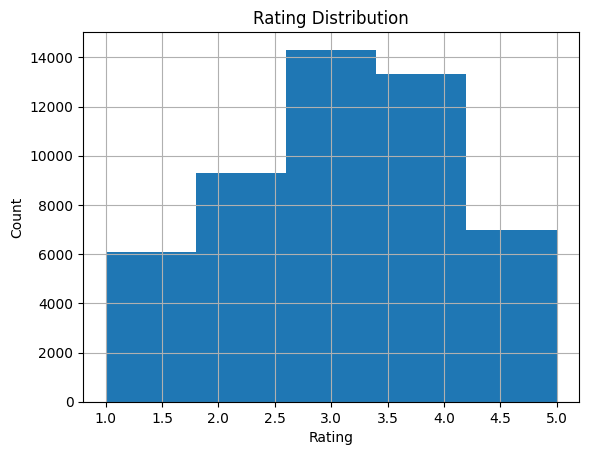

In [19]:
df["rating"].hist(bins=5)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

### 4.3 Sentiment distribution

In [20]:
df["sentiment"].value_counts()

sentiment
Positive    27204
Neutral     12639
Negative    10157
Name: count, dtype: int64

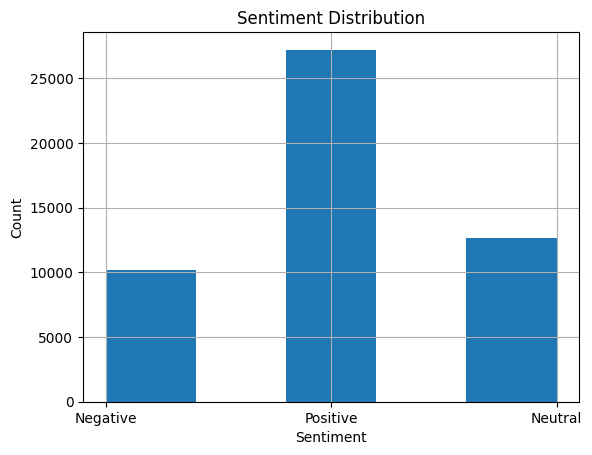

In [21]:
df["sentiment"].hist(bins=5)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()

### 4.4 Rating vs. Sentiment

In [22]:
pd.crosstab(df["rating"], df["sentiment"])

sentiment,Negative,Neutral,Positive
rating,,,
1.0,4804,1242,25
2.0,3939,4612,754
3.0,1360,5591,7358
4.0,54,1118,12143
5.0,0,76,6924


### 4.5 Price distribution

In [23]:
df["price_usd"].describe()

count    50000.000000
mean       689.795238
std        307.305506
min        180.020000
25%        450.800000
50%        640.805000
75%        901.405000
max       1499.890000
Name: price_usd, dtype: float64

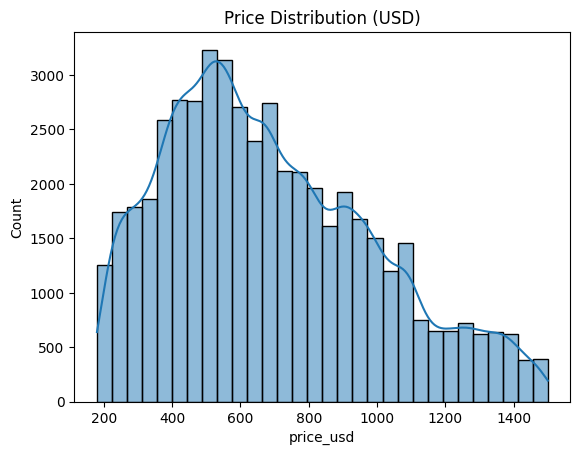

In [24]:
sns.histplot(df["price_usd"], bins=30, kde=True)
plt.title("Price Distribution (USD)")
plt.show()

### 4.6 Country & source breakdown

In [25]:
print(df["country"].value_counts())
print(df["source"].value_counts())

country
USA          6435
Brazil       6419
UAE          6261
Australia    6219
UK           6210
Canada       6170
Germany      6162
India        6124
Name: count, dtype: int64
source
eBay          12021
AliExpress     9531
Amazon         9513
Flipkart       9481
BestBuy        9454
Name: count, dtype: int64


## 5. Product-Level Summary Table
Aggregate reviews up to one row per (brand, model) so we can compare phones directly.

In [26]:
df["is_positive"] = df["sentiment"] == "Positive"

In [27]:
product_df = df.groupby(["brand", "model"]).agg({
    "price_usd": "median",
    "rating": "mean",
    "battery_life_rating": "mean",
    "camera_rating": "mean",
    "performance_rating": "mean",
    "design_rating": "mean",
    "display_rating": "mean",
    "verified_purchase": "mean",   # proportion of verified reviews
    "review_id": "count",          # number of reviews per model
    "is_positive": "mean",         # proportion of positive sentiment
}).reset_index()

product_df = product_df.rename(columns={
    "review_id": "review_count",
    "verified_purchase": "pct_verified",
    "is_positive": "pct_positive_sentiment",
})

print(product_df.shape)
product_df.head(10)

(22, 12)


,brand,model,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,pct_verified,review_count,pct_positive_sentiment
0,Apple,iPhone 13,1106.38,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,0.795133,1767,0.562535
1,Apple,iPhone 14,1094.51,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,0.815436,1788,0.558725
2,Apple,iPhone 15 Pro,1102.27,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,0.785276,1793,0.526492
3,Apple,iPhone SE,1101.03,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,0.796214,1796,0.535078
4,Google,Pixel 6,808.53,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,0.800336,2379,0.552333
5,Google,Pixel 7a,809.44,3.119530,2.715964,2.732172,2.725689,2.721232,2.748784,0.798217,2468,0.544165
6,Google,Pixel 8,799.52,3.122748,2.731881,2.715543,2.691244,2.743611,2.737746,0.820695,2387,0.541684
7,Motorola,Edge 50,514.92,3.087257,2.674730,2.701512,2.704536,2.688553,2.707559,0.803024,2315,0.530454
8,Motorola,Moto G Power,505.34,3.122501,2.715015,2.706083,2.716291,2.716291,2.719268,0.817950,2351,0.548703
9,Motorola,Razr 40,511.44,3.103967,2.713152,2.683925,2.730271,2.724843,2.724008,0.799165,2395,0.525261


### 5.1 Sanity checks on the aggregated table

In [28]:
print(product_df[["rating", "battery_life_rating", "camera_rating",
                   "performance_rating", "design_rating", "display_rating"]].std())

rating                 0.024880
battery_life_rating    0.020702
camera_rating          0.026468
performance_rating     0.034999
design_rating          0.030079
display_rating         0.026303
dtype: float64


In [29]:
print(df[["rating", "battery_life_rating", "camera_rating",
           "performance_rating", "design_rating", "display_rating"]].std())

rating                 1.218333
battery_life_rating    1.348270
camera_rating          1.345001
performance_rating     1.349208
design_rating          1.343346
display_rating         1.352121
dtype: float64


In [30]:
sample_model = df[df["model"] == "iPhone 13"]
sample_model[["rating", "camera_rating"]].describe()

,rating,camera_rating
count,1767.000000,1767.000000
mean,3.150538,2.754952
std,1.230040,1.344191
min,1.000000,1.000000
25%,2.000000,2.000000
50%,3.000000,3.000000
75%,4.000000,4.000000
max,5.000000,5.000000


In [31]:
df["review_date"].isnull().sum()

np.int64(0)

In [32]:
product_df[["pct_positive_sentiment", "pct_verified", "review_count"]].describe()

,pct_positive_sentiment,pct_verified,review_count
count,22.000000,22.000000,22.000000
mean,0.543838,0.801236,2272.727273
std,0.010540,0.009181,513.376051
min,0.525261,0.783039,1714.000000
25%,0.536699,0.797208,1790.000000
50%,0.544552,0.799751,2338.500000
75%,0.548932,0.803607,2423.500000
max,0.562535,0.820695,3597.000000


## 6. Price Segmentation with K-Means

### 6.1 Scale price and find the optimal number of clusters (Elbow Method)

k=1, inertia=22.00
k=2, inertia=4.65
k=3, inertia=1.87
k=4, inertia=0.56
k=5, inertia=0.29
k=6, inertia=0.07


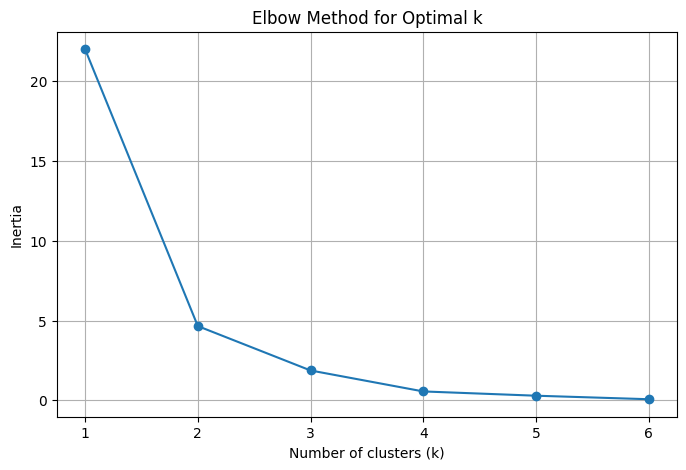

In [33]:
scaler = StandardScaler()
price_scaled = scaler.fit_transform(product_df[["price_usd"]])

inertia_values = []
k_range = range(1, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(price_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"k={k}, inertia={kmeans.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

### 6.2 Fit K-Means with k=3 and inspect the clusters

In [34]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
product_df["cluster"] = kmeans_final.fit_predict(price_scaled)

cluster_summary = product_df.groupby("cluster")["price_usd"].agg(["mean", "min", "max", "count"])
print(cluster_summary)

product_df[["brand", "model", "price_usd", "cluster"]].sort_values("price_usd")

              mean       min      max  count
cluster                                     
0         458.3950   392.820   514.92      8
1         803.0335   667.025   908.74     10
2        1101.0475  1094.510  1106.38      4


,brand,model,price_usd,cluster
14,Realme,Realme Narzo 70,392.820,0
13,Realme,Realme 12 Pro,396.410,0
19,Xiaomi,Mi 13 Pro,443.830,0
21,Xiaomi,Redmi Note 13,450.800,0
20,Xiaomi,Poco X6,451.600,0
8,Motorola,Moto G Power,505.340,0
9,Motorola,Razr 40,511.440,0
7,Motorola,Edge 50,514.920,0
10,OnePlus,OnePlus 11R,667.025,1
11,OnePlus,OnePlus 12,668.090,1


### 6.3 Label clusters as readable price segments

In [35]:
segment_map = {0: "Budget", 1: "Mid-range", 2: "Premium"}
product_df["segment"] = product_df["cluster"].map(segment_map)

product_df[["brand", "model", "price_usd", "cluster", "segment"]].sort_values("price_usd")

,brand,model,price_usd,cluster,segment
14,Realme,Realme Narzo 70,392.820,0,Budget
13,Realme,Realme 12 Pro,396.410,0,Budget
19,Xiaomi,Mi 13 Pro,443.830,0,Budget
21,Xiaomi,Redmi Note 13,450.800,0,Budget
20,Xiaomi,Poco X6,451.600,0,Budget
8,Motorola,Moto G Power,505.340,0,Budget
9,Motorola,Razr 40,511.440,0,Budget
7,Motorola,Edge 50,514.920,0,Budget
10,OnePlus,OnePlus 11R,667.025,1,Mid-range
11,OnePlus,OnePlus 12,668.090,1,Mid-range


### 6.4 Visualize the segments

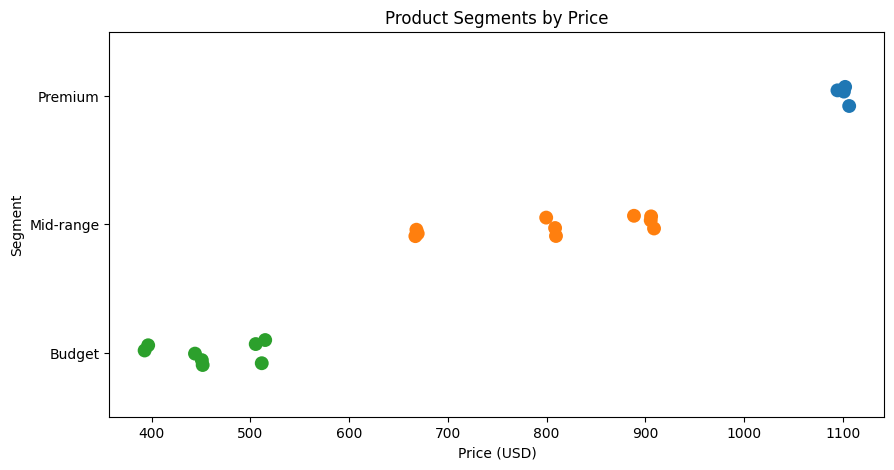

In [36]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=product_df, x="price_usd", y="segment", hue="segment", size=10, jitter=True)
plt.title("Product Segments by Price")
plt.xlabel("Price (USD)")
plt.ylabel("Segment")
plt.show()

## 7. Content-Based Phone Recommendation System
Recommend similar phones using cosine similarity over scaled numeric features plus one-hot encoded brand.

### 7.1 Build the feature matrix

In [37]:
brand_encoded = pd.get_dummies(product_df["brand"], prefix="brand")

In [38]:
numeric_features = product_df[[
    "price_usd", "rating", "battery_life_rating",
    "camera_rating", "performance_rating",
    "design_rating", "display_rating",
    "pct_positive_sentiment", "pct_verified",
]]

In [39]:
scaler_rec = StandardScaler()
numeric_scaled = scaler_rec.fit_transform(numeric_features)
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=numeric_features.columns, index=product_df.index)

In [40]:
recommendation_features = pd.concat([numeric_scaled_df, brand_encoded], axis=1)

print(recommendation_features.shape)
recommendation_features.head()

(22, 16)


,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,pct_positive_sentiment,pct_verified,brand_Apple,brand_Google,brand_Motorola,brand_OnePlus,brand_Realme,brand_Samsung,brand_Xiaomi
0,1.537585,1.388969,1.844734,1.441951,1.391390,1.753676,-0.347803,1.815649,-0.680458,True,False,False,False,False,False,False
1,1.488848,2.443625,1.019224,2.483244,0.179942,2.037855,1.547464,1.445615,1.583134,True,False,False,False,False,False,False
2,1.520710,-1.545867,-1.977878,-0.404846,-1.640591,-1.299817,-1.095817,-1.684456,-1.779398,True,False,False,False,False,False,False
3,1.515618,-0.818333,0.498771,-0.536653,0.427612,-0.769807,0.635920,-0.850684,-0.559959,True,False,False,False,False,False,False
4,0.314654,-0.186858,-0.275692,-0.297824,-0.812262,-0.252610,-0.146105,0.824909,-0.100348,False,True,False,False,False,False,False


### 7.2 Compute the similarity matrix

In [41]:
similarity_matrix = cosine_similarity(recommendation_features)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=product_df["model"],
    columns=product_df["model"],
)
similarity_df.round(2)

model,iPhone 13,iPhone 14,iPhone 15 Pro,iPhone SE,Pixel 6,Pixel 7a,Pixel 8,Edge 50,Moto G Power,Razr 40,OnePlus 11R,OnePlus 12,OnePlus Nord 3,Realme 12 Pro,Realme Narzo 70,Galaxy A55,Galaxy Note 20,Galaxy S24,Galaxy Z Flip,Mi 13 Pro,Poco X6,Redmi Note 13
model,,,,,,,,,,,,,,,,,,,,,,
iPhone 13,1.00,0.73,-0.44,0.02,-0.09,0.26,0.04,-0.83,-0.21,-0.53,-0.49,0.44,0.31,0.34,0.10,-0.32,0.80,-0.65,0.46,-0.72,0.07,-0.20
iPhone 14,0.73,1.00,-0.55,-0.16,-0.10,0.43,0.50,-0.69,0.14,-0.55,-0.57,0.08,0.36,0.34,0.11,-0.50,0.72,-0.77,0.42,-0.69,0.07,-0.10
iPhone 15 Pro,-0.44,-0.55,1.00,0.49,0.27,-0.15,-0.42,0.59,-0.49,0.20,0.48,0.05,-0.50,-0.71,-0.59,0.47,-0.64,0.84,-0.25,0.48,-0.31,-0.30
iPhone SE,0.02,-0.16,0.49,1.00,-0.06,0.19,-0.14,0.01,-0.47,0.18,0.05,-0.09,-0.09,-0.31,-0.20,0.09,-0.04,0.25,0.29,-0.08,-0.28,-0.52
Pixel 6,-0.09,-0.10,0.27,-0.06,1.00,0.20,0.15,0.04,0.01,-0.36,0.15,-0.06,0.06,-0.20,-0.48,0.38,-0.31,0.36,-0.13,0.40,-0.60,-0.09
Pixel 7a,0.26,0.43,-0.15,0.19,0.20,1.00,0.23,-0.27,-0.26,-0.13,-0.14,0.19,0.23,0.35,0.14,-0.67,0.28,-0.43,0.49,-0.35,0.08,-0.45
Pixel 8,0.04,0.50,-0.42,-0.14,0.15,0.23,1.00,-0.23,0.54,-0.04,-0.45,-0.55,-0.05,-0.01,0.05,0.02,0.28,-0.30,-0.17,-0.28,0.05,0.19
Edge 50,-0.83,-0.69,0.59,0.01,0.04,-0.27,-0.23,1.00,0.22,0.61,0.54,-0.32,-0.45,-0.39,-0.20,0.31,-0.76,0.69,-0.46,0.60,0.11,0.18
Moto G Power,-0.21,0.14,-0.49,-0.47,0.01,-0.26,0.54,0.22,1.00,0.16,-0.15,-0.59,0.14,0.20,0.19,0.09,0.01,-0.19,-0.27,0.08,0.12,0.57


### 7.3 Recommendation function

In [42]:
def recommend_similar_phones(model_name, top_n=3):
    """Return the top_n phones most similar to `model_name`."""
    similar_scores = similarity_df.loc[model_name]
    similar_scores = similar_scores.sort_values(ascending=False)
    similar_scores = similar_scores.drop(model_name)  # exclude the phone itself
    return similar_scores.head(top_n)


print(recommend_similar_phones("iPhone 13"))
print(recommend_similar_phones("Redmi Note 13"))

model
Galaxy Note 20    0.799129
iPhone 14         0.729103
Galaxy Z Flip     0.461220
Name: iPhone 13, dtype: float64
model
Moto G Power    0.569143
Poco X6         0.403993
Mi 13 Pro       0.381360
Name: Redmi Note 13, dtype: float64


## 8. Save Final Outputs

In [43]:
product_df.to_csv("product_segments.csv", index=False)
similarity_df.to_csv("similarity_matrix.csv")

print("✔ Saved product_segments.csv and similarity_matrix.csv")

✔ Saved product_segments.csv and similarity_matrix.csv
